In [1]:
# Importações

import pandas as pd
import matplotlib.pyplot as plt
import unicodedata

print("Pronto!")

Pronto!


In [3]:
# Ler dados

df = pd.read_csv("2004-2021.tsv", sep="\t")

print("Pronto!")

Pronto!


In [5]:
# Visualizar cabeçalho e primeiras linhas

df.head(2)

,DATA INICIAL,DATA FINAL,REGIÃO,ESTADO,PRODUTO,NÚMERO DE POSTOS PESQUISADOS,UNIDADE DE MEDIDA,PREÇO MÉDIO REVENDA,DESVIO PADRÃO REVENDA,PREÇO MÍNIMO REVENDA,PREÇO MÁXIMO REVENDA,MARGEM MÉDIA REVENDA,COEF DE VARIAÇÃO REVENDA,PREÇO MÉDIO DISTRIBUIÇÃO,DESVIO PADRÃO DISTRIBUIÇÃO,PREÇO MÍNIMO DISTRIBUIÇÃO,PREÇO MÁXIMO DISTRIBUIÇÃO,COEF DE VARIAÇÃO DISTRIBUIÇÃO
0,2004-05-09,2004-05-15,CENTRO OESTE,DISTRITO FEDERAL,ETANOL HIDRATADO,127,R$/l,1.288,0.016,1.19,1.350,0.463,0.012,0.825,0.11,0.4201,0.9666,0.133
1,2004-05-09,2004-05-15,CENTRO OESTE,GOIAS,ETANOL HIDRATADO,387,R$/l,1.162,0.114,0.89,1.449,0.399,0.098,0.763,0.088,0.5013,1.05,0.115


In [6]:
# Tamanho do dataframe

df.shape

(120823, 18)

In [7]:
# Limpeza inicial

df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

df["data_inicial"] = pd.to_datetime(df["data_inicial"])

df["data_final"] = pd.to_datetime(df["data_final"])

In [9]:
# Remover acentos

import unicodedata

df["produto"] = df["produto"].apply(
lambda x: unicodedata.normalize("NFKD", x).encode("ASCII", "ignore").decode("utf-8"))

df.head(2)

,data_inicial,data_final,região,estado,produto,número_de_postos_pesquisados,unidade_de_medida,preço_médio_revenda,desvio_padrão_revenda,preço_mínimo_revenda,preço_máximo_revenda,margem_média_revenda,coef_de_variação_revenda,preço_médio_distribuição,desvio_padrão_distribuição,preço_mínimo_distribuição,preço_máximo_distribuição,coef_de_variação_distribuição
0,2004-05-09,2004-05-15,CENTRO OESTE,DISTRITO FEDERAL,ETANOL HIDRATADO,127,R$/l,1.288,0.016,1.19,1.350,0.463,0.012,0.825,0.11,0.4201,0.9666,0.133
1,2004-05-09,2004-05-15,CENTRO OESTE,GOIAS,ETANOL HIDRATADO,387,R$/l,1.162,0.114,0.89,1.449,0.399,0.098,0.763,0.088,0.5013,1.05,0.115


# Consolidação

In [10]:
# Criar coluna "ano"

df["ano"] = df["data_inicial"].dt.year

In [12]:
# Código fundamental

# df[condição].groupby(chave)[coluna].função()

gasolina = df[df["produto"] == "GASOLINA COMUM"].groupby("ano")["preço_médio_revenda"].mean()
etanol = df[df["produto"] == "ETANOL HIDRATADO"].groupby("ano")["preço_médio_revenda"].mean()

# Tradução mental da sintaxe:
# "Pegue o dataframe df e mantenha apenas as linhas onde o produto é gasolina comum."
# "Agora agrupe esses dados por ano"
# "Dentro de cada grupo, olhe apenas para a coluna preço."
# "Calcule a média do preço para cada ano."

# Gráficos

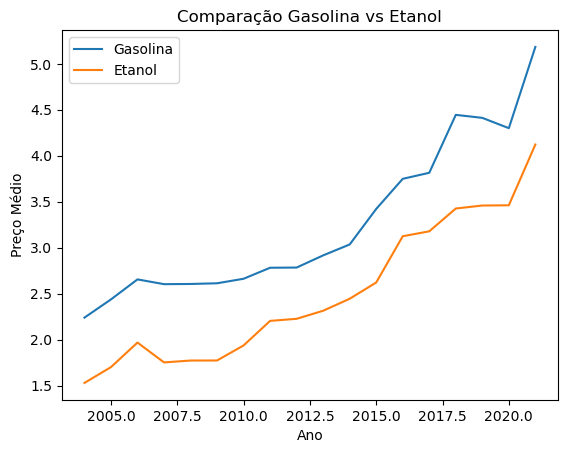

In [13]:
plt.figure()

plt.plot(gasolina.index, gasolina.values, label = "Gasolina")
plt.plot(etanol.index, etanol.values, label = "Etanol")

plt.legend()
plt.xlabel("Ano")
plt.ylabel("Preço Médio")
plt.title("Comparação Gasolina vs Etanol")

plt.show()

In [37]:
# Razão

razao = etanol / gasolina

In [46]:
razao

ano
2004    0.682620
2005    0.697736
2006    0.741111
2007    0.672946
2008    0.680188
2009    0.678460
2010    0.727478
2011    0.792112
2012    0.799662
2013    0.793455
2014    0.805343
2015    0.766018
2016    0.833382
2017    0.833037
2018    0.770754
2019    0.783832
2020    0.804889
2021    0.795099
Name: preço_médio_revenda, dtype: float64

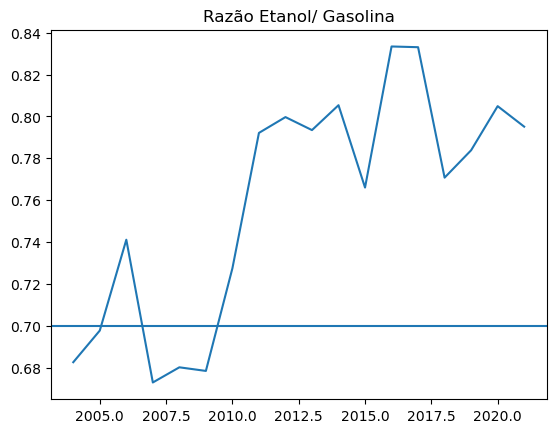

In [19]:
# Gráfico da razão EH/ GC

plt.figure()
plt.plot(razao.index, razao.values)
plt.axhline(0.7) #linha de decisão
plt.title("Razão Etanol/ Gasolina")
plt.show()

In [45]:
diferenca = gasolina - etanol

diferenca

ano
2004    0.710569
2005    0.736609
2006    0.687270
2007    0.851208
2008    0.833087
2009    0.839976
2010    0.725350
2011    0.578231
2012    0.557636
2013    0.602280
2014    0.590736
2015    0.800509
2016    0.624625
2017    0.636886
2018    1.018960
2019    0.953763
2020    0.838967
2021    1.062204
Name: preço_médio_revenda, dtype: float64

# 1. Em quais anos a distância entre gasolina e etanol é maior?

In [42]:
# 2018
# 2021

# 2. Esse anos coincidem com:

In [43]:
# Razão alta

# 3. Existe mudança estrutural após 2015?

In [47]:
# Sim, após 2015 houve uma evolução acentuada no preço do etanol e da gasolina.

# 4. Em quantos anos escolheria etanol?

In [48]:
razao < 0.7

ano
2004     True
2005     True
2006    False
2007     True
2008     True
2009     True
2010    False
2011    False
2012    False
2013    False
2014    False
2015    False
2016    False
2017    False
2018    False
2019    False
2020    False
2021    False
Name: preço_médio_revenda, dtype: bool

In [ ]:
# 2004, 2005, 2007, 2008, 2009     